In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import json
import math
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    CSVLogger
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_ROOT = "/content/drive/MyDrive/RNN/DeepFire/Forest Fire Dataset"
OUTPUT_DIR = "/content/fire_wow_output"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

MODEL_NAME = "efficientnetb0"
EPOCHS_HEAD = 10
EPOCHS_FINE = 20

LR_HEAD = 1e-3
LR_FINE = 1e-5

VAL_SPLIT_FROM_TRAIN = 0.15
MISCLASSIFIED_LIMIT = 24

CLASS_NAMES = ["fire", "no_fire"]

os.makedirs(OUTPUT_DIR, exist_ok=True)
for sub in ["prepared_data", "models", "plots", "reports", "gradcam"]:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled")
except Exception as e:
    print("Mixed precision not enabled:", e)

Mixed precision enabled


In [4]:
def list_image_files(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    folder = Path(folder)
    if not folder.exists():
        return []
    return [p for p in folder.rglob("*") if p.suffix.lower() in exts]

def discover_class_dir(base_dir, aliases):
    if not os.path.exists(base_dir):
        return None
    entries = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    lowered = {e.lower(): e for e in entries}
    for alias in aliases:
        if alias.lower() in lowered:
            return os.path.join(base_dir, lowered[alias.lower()])
    return None

def safe_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def prepare_dataset_structure(dataset_root, prepared_root, val_ratio=0.15):
    dataset_root = Path(dataset_root)
    prepared_root = Path(prepared_root)

    if prepared_root.exists():
        shutil.rmtree(prepared_root)
    prepared_root.mkdir(parents=True, exist_ok=True)

    train_root = dataset_root / "training"
    if not train_root.exists():
        train_root = dataset_root / "train"

    test_root = dataset_root / "testing"
    if not test_root.exists():
        test_root = dataset_root / "test"

    if not train_root.exists():
        raise FileNotFoundError("Train folder not found. Expected training/ or train/")
    if not test_root.exists():
        raise FileNotFoundError("Test folder not found. Expected testing/ or test/")

    class_aliases = {
        "fire": ["fire", "fires", "with_fire", "withfire"],
        "no_fire": ["no_fire", "nofire", "non_fire", "nonfire", "not_fire", "notfire", "no fire", "not fire", "no-fire"]
    }

    src_train = {}
    src_test = {}

    for cname, aliases in class_aliases.items():
        src_train[cname] = discover_class_dir(str(train_root), aliases)
        src_test[cname] = discover_class_dir(str(test_root), aliases)

    if any(v is None for v in src_train.values()):
        raise FileNotFoundError(f"Could not find both classes inside {train_root}")
    if any(v is None for v in src_test.values()):
        raise FileNotFoundError(f"Could not find both classes inside {test_root}")

    for cname in ["fire", "no_fire"]:
        files = list_image_files(src_train[cname])
        random.shuffle(files)
        n_val = max(1, int(len(files) * val_ratio))
        val_files = files[:n_val]
        train_files = files[n_val:]

        for i, fp in enumerate(train_files):
            safe_copy(fp, prepared_root / "train" / cname / f"train_{cname}_{i}{fp.suffix.lower()}")
        for i, fp in enumerate(val_files):
            safe_copy(fp, prepared_root / "val" / cname / f"val_{cname}_{i}{fp.suffix.lower()}")

        test_files = list_image_files(src_test[cname])
        for i, fp in enumerate(test_files):
            safe_copy(fp, prepared_root / "test" / cname / f"test_{cname}_{i}{fp.suffix.lower()}")

    return str(prepared_root)

def count_images_per_split(prepared_root):
    rows = []
    for split in ["train", "val", "test"]:
        for cname in ["fire", "no_fire"]:
            rows.append([
                split,
                cname,
                len(list_image_files(Path(prepared_root) / split / cname))
            ])
    return pd.DataFrame(rows, columns=["split", "class", "count"])


Train fire exists    : True
Train nofire exists  : True
Test dir exists      : True
Nb train fire   : 771
Nb train nofire : 760
Nb test images: 380
Test fire copied   : 190
Test no_fire copied: 190
Unknown test files : 0


,split,class,count
0,train,fire,656
1,train,no_fire,646
2,val,fire,115
3,val,no_fire,114
4,test,fire,190
5,test,no_fire,190


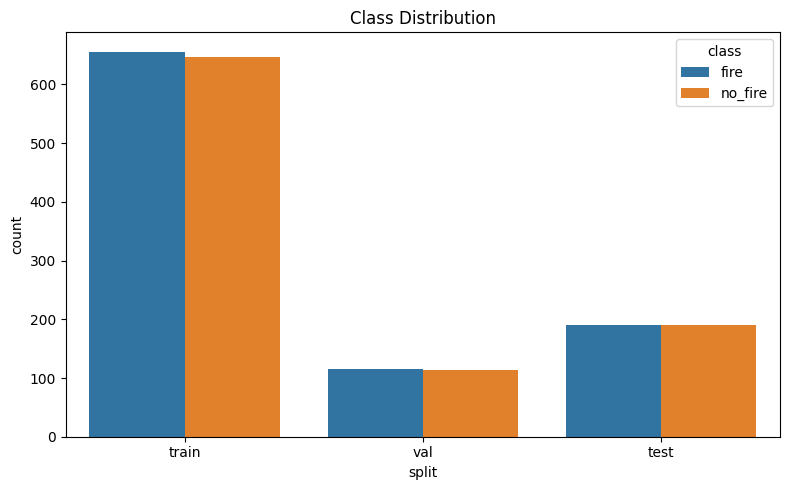

In [5]:
prepared_root = os.path.join(OUTPUT_DIR, "prepared_data")

# on nettoie l'ancien dossier préparé si besoin
if os.path.exists(prepared_root):
    shutil.rmtree(prepared_root)

os.makedirs(prepared_root, exist_ok=True)

# chemins exacts de TON dataset
train_fire_dir = os.path.join(DATASET_ROOT, "Training", "fire")
train_nofire_dir = os.path.join(DATASET_ROOT, "Training", "nofire")
test_dir = os.path.join(DATASET_ROOT, "Testing")

print("Train fire exists    :", os.path.exists(train_fire_dir))
print("Train nofire exists  :", os.path.exists(train_nofire_dir))
print("Test dir exists      :", os.path.exists(test_dir))

# lister les fichiers train
train_fire_files = list_image_files(train_fire_dir)
train_nofire_files = list_image_files(train_nofire_dir)

print("Nb train fire   :", len(train_fire_files))
print("Nb train nofire :", len(train_nofire_files))

# split train -> train + val
random.shuffle(train_fire_files)
random.shuffle(train_nofire_files)

n_val_fire = max(1, int(len(train_fire_files) * VAL_SPLIT_FROM_TRAIN))
n_val_nofire = max(1, int(len(train_nofire_files) * VAL_SPLIT_FROM_TRAIN))

val_fire_files = train_fire_files[:n_val_fire]
real_train_fire_files = train_fire_files[n_val_fire:]

val_nofire_files = train_nofire_files[:n_val_nofire]
real_train_nofire_files = train_nofire_files[n_val_nofire:]

# copier train/val
for fp in real_train_fire_files:
    safe_copy(fp, Path(prepared_root) / "train" / "fire" / fp.name)

for fp in val_fire_files:
    safe_copy(fp, Path(prepared_root) / "val" / "fire" / fp.name)

for fp in real_train_nofire_files:
    safe_copy(fp, Path(prepared_root) / "train" / "no_fire" / fp.name)

for fp in val_nofire_files:
    safe_copy(fp, Path(prepared_root) / "val" / "no_fire" / fp.name)


test_files = list_image_files(test_dir)
print("Nb test images:", len(test_files))

fire_keywords = ["fire"]
nofire_keywords = ["nofire", "no_fire", "no-fire", "notfire", "not_fire", "not-fire"]

test_fire_count = 0
test_nofire_count = 0
unknown_test = []

for fp in test_files:
    name = fp.name.lower()

    if any(k in name for k in nofire_keywords):
        safe_copy(fp, Path(prepared_root) / "test" / "no_fire" / fp.name)
        test_nofire_count += 1
    elif any(k in name for k in fire_keywords):
        safe_copy(fp, Path(prepared_root) / "test" / "fire" / fp.name)
        test_fire_count += 1
    else:
        unknown_test.append(fp.name)

print("Test fire copied   :", test_fire_count)
print("Test no_fire copied:", test_nofire_count)
print("Unknown test files :", len(unknown_test))

if len(unknown_test) > 0:
    print("\nExemples de fichiers non reconnus :")
    print(unknown_test[:20])


counts_df = count_images_per_split(prepared_root)
display(counts_df)

plt.figure(figsize=(8,5))
sns.barplot(data=counts_df, x="split", y="count", hue="class")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

Train fire exists   : True
Train nofire exists : True
Test dir exists     : True
Nb train fire   : 771
Nb train nofire : 760
Nb test images  : 380
Test fire copied   : 190
Test no_fire copied: 190
Unknown test files : 0


,split,class,count
0,train,fire,656
1,train,no_fire,646
2,val,fire,115
3,val,no_fire,114
4,test,fire,190
5,test,no_fire,190


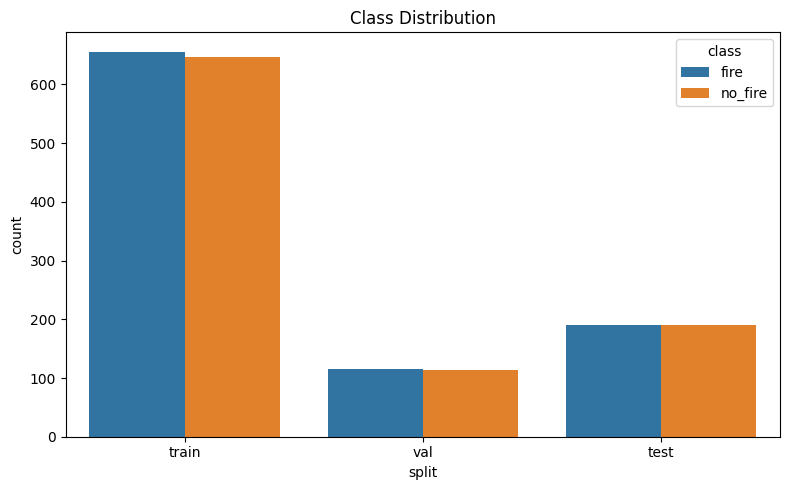

In [6]:
prepared_root = os.path.join(OUTPUT_DIR, "prepared_data")

if os.path.exists(prepared_root):
    shutil.rmtree(prepared_root)
os.makedirs(prepared_root, exist_ok=True)

train_fire_dir = os.path.join(DATASET_ROOT, "Training", "fire")
train_nofire_dir = os.path.join(DATASET_ROOT, "Training", "nofire")
test_dir = os.path.join(DATASET_ROOT, "Testing")

print("Train fire exists   :", os.path.exists(train_fire_dir))
print("Train nofire exists :", os.path.exists(train_nofire_dir))
print("Test dir exists     :", os.path.exists(test_dir))

train_fire_files = list_image_files(train_fire_dir)
train_nofire_files = list_image_files(train_nofire_dir)
test_files = list_image_files(test_dir)

print("Nb train fire   :", len(train_fire_files))
print("Nb train nofire :", len(train_nofire_files))
print("Nb test images  :", len(test_files))

random.shuffle(train_fire_files)
random.shuffle(train_nofire_files)

n_val_fire = max(1, int(len(train_fire_files) * VAL_SPLIT_FROM_TRAIN))
n_val_nofire = max(1, int(len(train_nofire_files) * VAL_SPLIT_FROM_TRAIN))

val_fire_files = train_fire_files[:n_val_fire]
real_train_fire_files = train_fire_files[n_val_fire:]

val_nofire_files = train_nofire_files[:n_val_nofire]
real_train_nofire_files = train_nofire_files[n_val_nofire:]

for fp in real_train_fire_files:
    safe_copy(fp, Path(prepared_root) / "train" / "fire" / fp.name)

for fp in val_fire_files:
    safe_copy(fp, Path(prepared_root) / "val" / "fire" / fp.name)

for fp in real_train_nofire_files:
    safe_copy(fp, Path(prepared_root) / "train" / "no_fire" / fp.name)

for fp in val_nofire_files:
    safe_copy(fp, Path(prepared_root) / "val" / "no_fire" / fp.name)


fire_keywords = ["fire"]
nofire_keywords = ["nofire", "no_fire", "no-fire", "notfire", "not_fire", "not-fire"]

test_fire_count = 0
test_nofire_count = 0
unknown_test = []

for fp in test_files:
    name = fp.name.lower()

    if any(k in name for k in nofire_keywords):
        safe_copy(fp, Path(prepared_root) / "test" / "no_fire" / fp.name)
        test_nofire_count += 1
    elif any(k in name for k in fire_keywords):
        safe_copy(fp, Path(prepared_root) / "test" / "fire" / fp.name)
        test_fire_count += 1
    else:
        unknown_test.append(fp.name)

print("Test fire copied   :", test_fire_count)
print("Test no_fire copied:", test_nofire_count)
print("Unknown test files :", len(unknown_test))

if len(unknown_test) > 0:
    print("\nExemples de fichiers non reconnus :")
    print(unknown_test[:20])

counts_df = count_images_per_split(prepared_root)
display(counts_df)

plt.figure(figsize=(8,5))
sns.barplot(data=counts_df, x="split", y="count", hue="class")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

counts_df.to_csv(os.path.join(OUTPUT_DIR, "reports", "split_counts.csv"), index=False)

In [7]:
print("Exemples de noms dans Testing :")
for fp in test_files[:50]:
    print(fp.name)

Exemples de noms dans Testing :
fire_0340.jpg
fire_0436.jpg
fire_0329.jpg
fire_0403.jpg
fire_0084.jpg
fire_0447.jpg
fire_0461.jpg
fire_0063.jpg
fire_0432.jpg
fire_0398.jpg
fire_0247.jpg
fire_0048.jpg
fire_0367.jpg
fire_0174.jpg
fire_0453.jpg
fire_0205.jpg
fire_0500.jpg
fire_0442.jpg
fire_0449.jpg
fire_0335.jpg
fire_0107.jpg
fire_0371.jpg
fire_0314.jpg
fire_0271.jpg
fire_0277.jpg
fire_0300.jpg
fire_0297.jpg
fire_0475.jpg
fire_0169.jpg
fire_0390.jpg
fire_0426.jpg
fire_0411.jpg
fire_0139.jpg
fire_0275.jpg
fire_0395.jpg
fire_0482.jpg
fire_0289.jpg
fire_0355.jpg
fire_0456.jpg
fire_0502.jpg
fire_0325.jpg
fire_0217.jpg
fire_0143.jpg
fire_0188.jpg
fire_0097.jpg
fire_0145.jpg
fire_0179.jpg
fire_0305.jpg
fire_0484.jpg
fire_0038.jpg


In [8]:
train_dir = os.path.join(prepared_root, "train")
val_dir = os.path.join(prepared_root, "val")
test_dir = os.path.join(prepared_root, "test")

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 1302 files belonging to 2 classes.
Found 229 files belonging to 2 classes.
Found 380 files belonging to 2 classes.


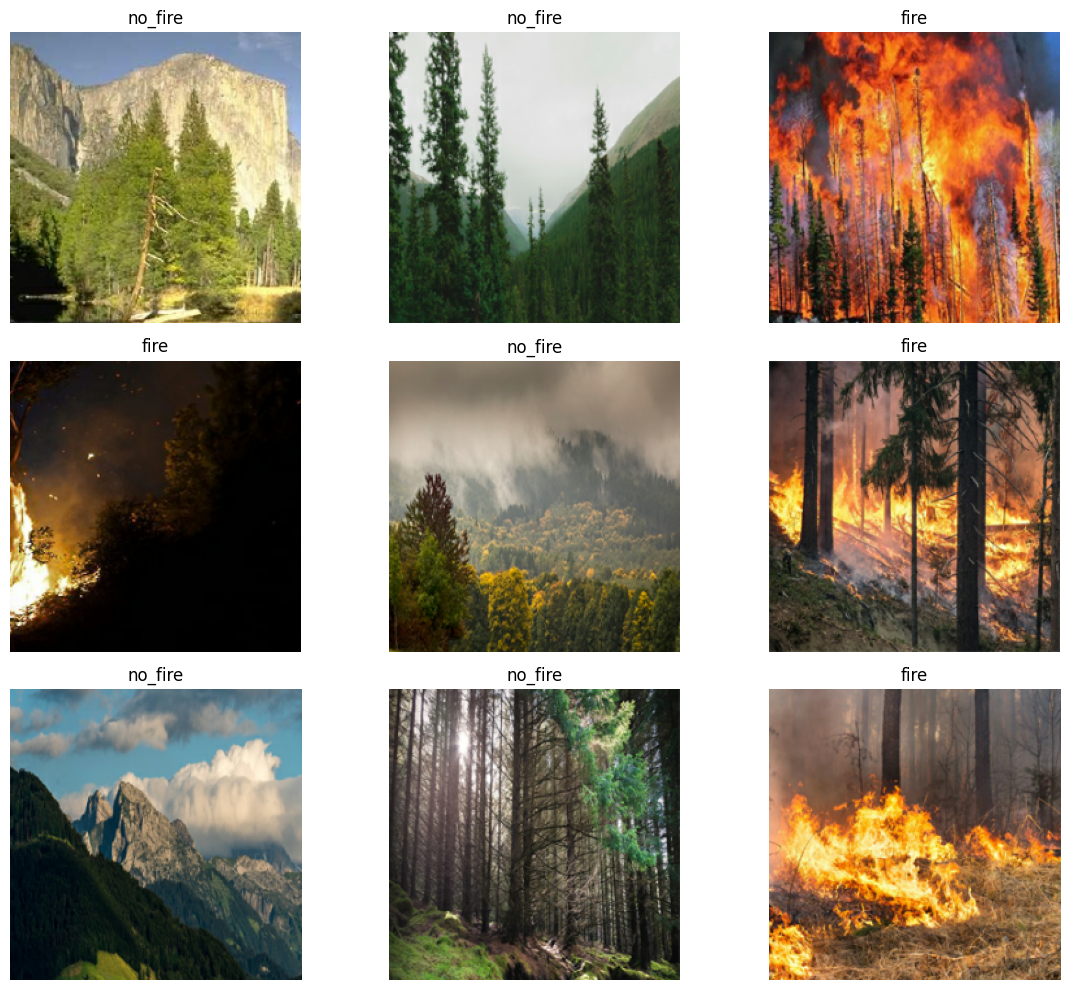

In [9]:
plt.figure(figsize=(12,10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i].numpy()[0])])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
def get_preprocess_and_backbone(model_name, input_shape):
    model_name = model_name.lower()

    if model_name == "efficientnetb0":
        preprocess = tf.keras.applications.efficientnet.preprocess_input
        backbone = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
    elif model_name == "resnet50":
        preprocess = tf.keras.applications.resnet50.preprocess_input
        backbone = tf.keras.applications.ResNet50(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
    elif model_name == "vgg19":
        preprocess = tf.keras.applications.vgg19.preprocess_input
        backbone = tf.keras.applications.VGG19(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape
        )
    else:
        raise ValueError("MODEL_NAME must be one of: efficientnetb0, resnet50, vgg19")

    return preprocess, backbone


def build_model(model_name="efficientnetb0", input_shape=(224,224,3)):
    preprocess, backbone = get_preprocess_and_backbone(model_name, input_shape)
    backbone.trainable = False

    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomContrast(0.10),
    ], name="augmentation")

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = preprocess(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = keras.Model(inputs, outputs)
    return model, backbone

In [11]:
def compile_model(model, lr):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ],
    )

def make_callbacks(name_prefix):
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            os.path.join(OUTPUT_DIR, "models", f"{name_prefix}_best.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(
            os.path.join(OUTPUT_DIR, "reports", f"{name_prefix}_training_log.csv"),
            append=False
        )
    ]

def unfreeze_top_layers(backbone, percentage=0.25):
    total = len(backbone.layers)
    start = int(total * (1 - percentage))
    for i, layer in enumerate(backbone.layers):
        layer.trainable = i >= start
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

In [12]:
model, backbone = build_model(MODEL_NAME, input_shape=IMG_SIZE + (3,))
compile_model(model, LR_HEAD)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=make_callbacks(f"{MODEL_NAME}_head"),
    verbose=1
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.8976 - auc: 0.9513 - loss: 0.2322 - precision: 0.9034 - recall: 0.8935
Epoch 1: val_loss improved from None to 0.05522, saving model to /content/fire_wow_output/models/efficientnetb0_head_best.keras

Epoch 1: finished saving model to /content/fire_wow_output/models/efficientnetb0_head_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 75s 897ms/step - accuracy: 0.9485 - auc: 0.9894 - loss: 0.1373 - precision: 0.9516 - recall: 0.9443 - val_accuracy: 0.9913 - val_auc: 0.9996 - val_loss: 0.0552 - val_precision: 0.9912 - val_recall: 0.9912 - learning_rate: 0.0010
Epoch 2/10
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9822 - auc: 0.9981 - loss: 0.0512 - precision: 0.9775 - recall: 0.9861
Epoch 2: val_loss improved from 0.05522 to 0.04638, saving model to /content/fire_wow_output/models/efficientnetb0_head_best.keras

Epoch 2: finished saving model to /content/fire_wow_output/models/efficientnetb0_head_best.keras
41/41 ━━━━━━━━━━

In [14]:
unfreeze_top_layers(backbone, percentage=0.25)
compile_model(model, LR_FINE)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=make_callbacks(f"{MODEL_NAME}_fine"),
    verbose=1
)

Epoch 1/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9884 - auc: 0.9991 - loss: 0.0329 - precision: 0.9766 - recall: 0.9998
Epoch 1: val_loss improved from None to 0.00700, saving model to /content/fire_wow_output/models/efficientnetb0_fine_best.keras

Epoch 1: finished saving model to /content/fire_wow_output/models/efficientnetb0_fine_best.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 44s 449ms/step - accuracy: 0.9885 - auc: 0.9982 - loss: 0.0363 - precision: 0.9788 - recall: 0.9985 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0070 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9932 - auc: 0.9988 - loss: 0.0207 - precision: 0.9871 - recall: 0.9990
Epoch 2: val_loss improved from 0.00700 to 0.00640, saving model to /content/fire_wow_output/models/efficientnetb0_fine_best.keras

Epoch 2: finished saving model to /content/fire_wow_output/models/efficientnetb0_fine_best.keras
41/41 ━━━━━━

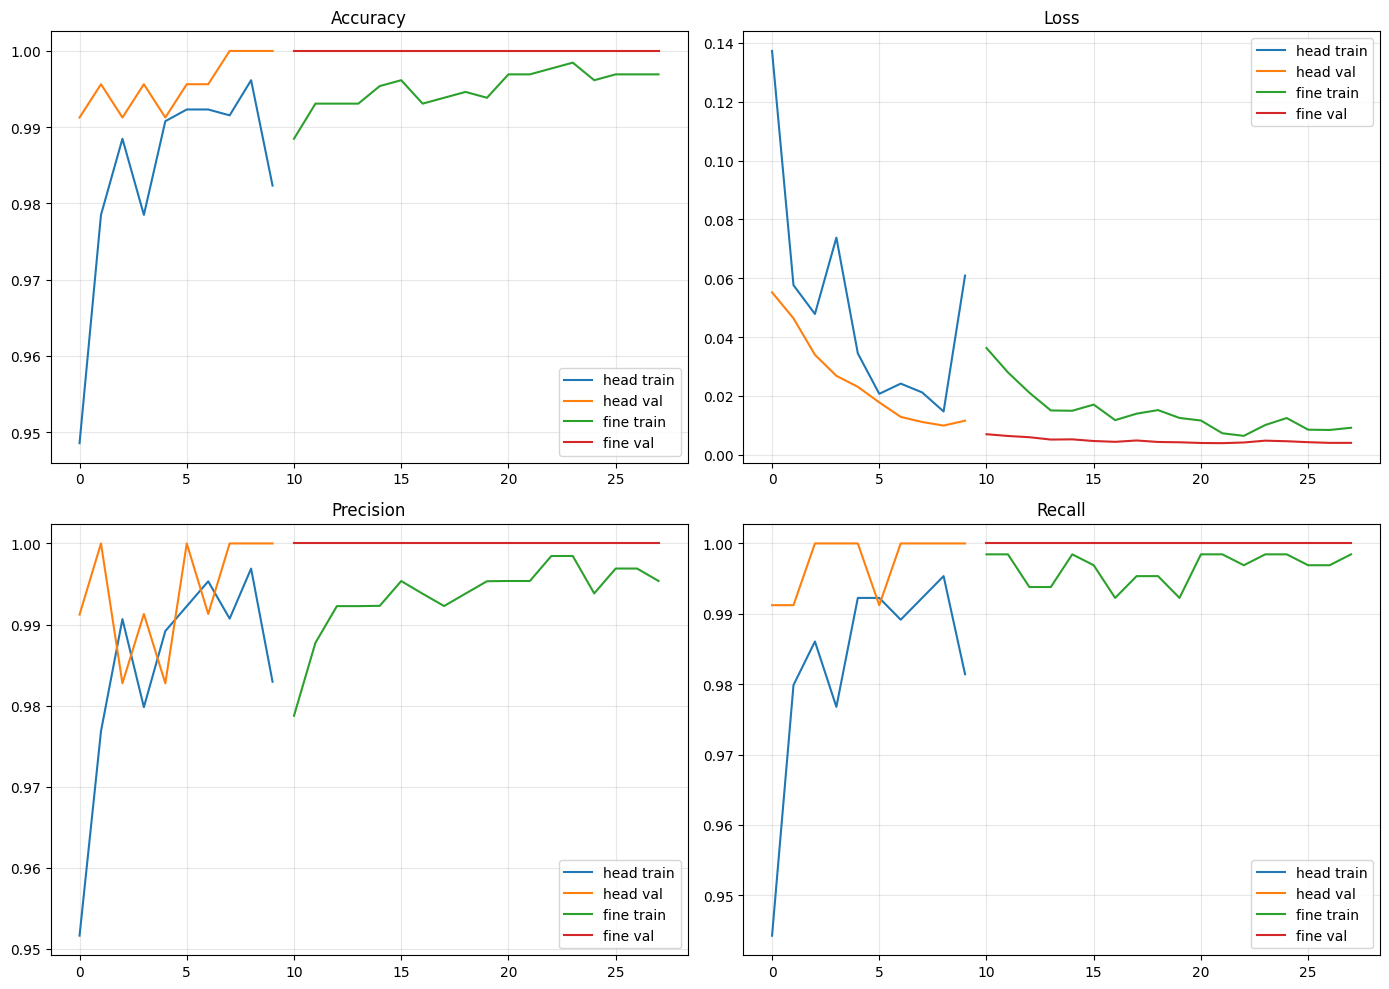

In [15]:
def plot_training_curves(history_head, history_fine):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metric_pairs = [("accuracy", "Accuracy"), ("loss", "Loss"), ("precision", "Precision"), ("recall", "Recall")]

    for ax, (metric, title) in zip(axes.ravel(), metric_pairs):
        if metric in history_head.history:
            ax.plot(history_head.history[metric], label="head train")
        if f"val_{metric}" in history_head.history:
            ax.plot(history_head.history[f"val_{metric}"], label="head val")

        offset = len(history_head.history.get(metric, []))

        if metric in history_fine.history:
            ax.plot(
                np.arange(offset, offset + len(history_fine.history[metric])),
                history_fine.history[metric],
                label="fine train"
            )
        if f"val_{metric}" in history_fine.history:
            ax.plot(
                np.arange(offset, offset + len(history_fine.history[f"val_{metric}"])),
                history_fine.history[f"val_{metric}"],
                label="fine val"
            )

        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_training_curves.png"), dpi=220)
    plt.show()

plot_training_curves(history_head, history_fine)

In [16]:
def extract_true_labels(dataset):
    y_true = []
    for _, labels in dataset:
        y_true.extend(labels.numpy().reshape(-1).astype(int).tolist())
    return np.array(y_true)

y_prob = model.predict(test_ds, verbose=1).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = extract_true_labels(test_ds)

12/12 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


In [17]:
from tensorflow.keras.models import load_model

best_model_path = os.path.join(OUTPUT_DIR, "models", f"{MODEL_NAME}_fine_best.keras")

if os.path.exists(best_model_path):
    print("Chargement du meilleur modèle depuis:", best_model_path)
    model = load_model(best_model_path)
else:
    print("Attention: best model non trouvé, on garde le modèle actuel.")

Chargement du meilleur modèle depuis: /content/fire_wow_output/models/efficientnetb0_fine_best.keras


In [18]:
final_model_path = os.path.join(OUTPUT_DIR, "models", f"final_{MODEL_NAME}.keras")
model.save(final_model_path)
print("Modèle final sauvegardé dans:", final_model_path)

Modèle final sauvegardé dans: /content/fire_wow_output/models/final_efficientnetb0.keras


In [19]:
metrics_summary = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1_score": f1_score(y_true, y_pred, zero_division=0),
    "roc_auc": auc(*roc_curve(y_true, y_prob)[:2]),
    "avg_precision": average_precision_score(y_true, y_prob),
}

metrics_df = pd.DataFrame([metrics_summary])
display(metrics_df)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "reports", f"{MODEL_NAME}_metrics_summary.csv"), index=False)

,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,0.997368,1.0,0.994737,0.997361,1.0,1.0


In [20]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
display(report_df)
report_df.to_csv(os.path.join(OUTPUT_DIR, "reports", f"{MODEL_NAME}_classification_report.csv"))

,precision,recall,f1-score,support
fire,0.994764,1.000000,0.997375,190.000000
no_fire,1.000000,0.994737,0.997361,190.000000
accuracy,0.997368,0.997368,0.997368,0.997368
macro avg,0.997382,0.997368,0.997368,380.000000
weighted avg,0.997382,0.997368,0.997368,380.000000


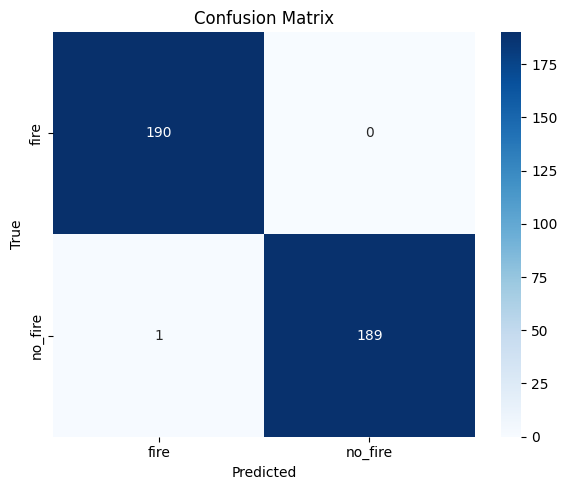

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_confusion_matrix.png"), dpi=220)
plt.show()

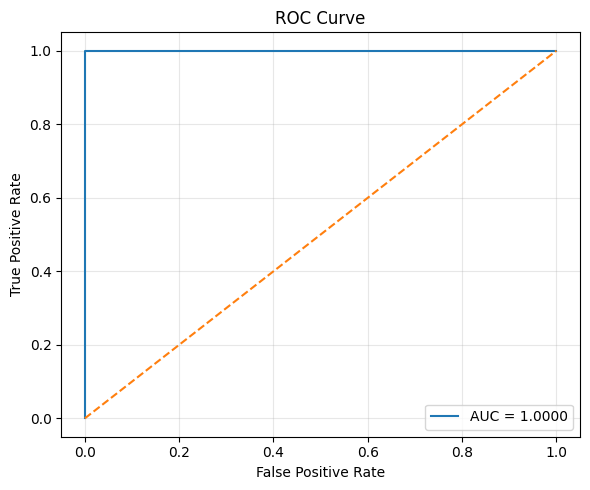

In [22]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_roc_curve.png"), dpi=220)
plt.show()

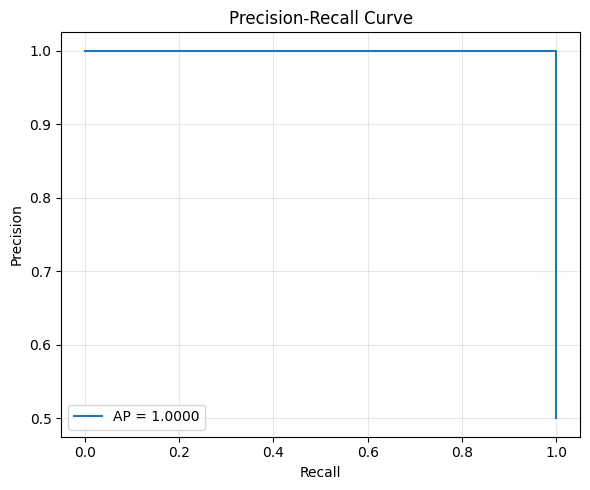

In [23]:
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_pr_curve.png"), dpi=220)
plt.show()

,threshold,accuracy,precision,recall,f1
0,0.10,0.994737,0.989583,1.000000,0.994764
1,0.15,1.000000,1.000000,1.000000,1.000000
2,0.20,0.997368,1.000000,0.994737,0.997361
3,0.25,0.997368,1.000000,0.994737,0.997361
4,0.30,0.997368,1.000000,0.994737,0.997361
5,0.35,0.997368,1.000000,0.994737,0.997361
6,0.40,0.997368,1.000000,0.994737,0.997361
7,0.45,0.997368,1.000000,0.994737,0.997361
8,0.50,0.997368,1.000000,0.994737,0.997361
9,0.55,0.997368,1.000000,0.994737,0.997361


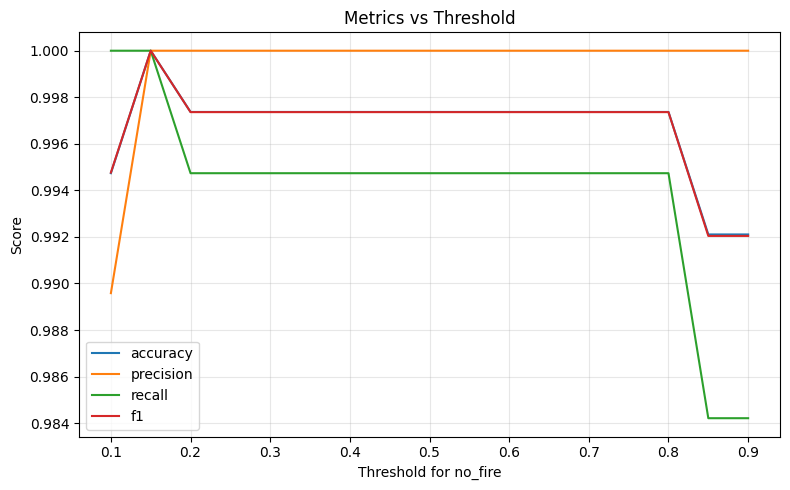

In [24]:
thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for th in thresholds:
    pred_th = (y_prob >= th).astype(int)
    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_true, pred_th),
        "precision": precision_score(y_true, pred_th, zero_division=0),
        "recall": recall_score(y_true, pred_th, zero_division=0),
        "f1": f1_score(y_true, pred_th, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

plt.figure(figsize=(8,5))
for col in ["accuracy", "precision", "recall", "f1"]:
    plt.plot(threshold_df["threshold"], threshold_df[col], label=col)
plt.xlabel("Threshold for no_fire")
plt.ylabel("Score")
plt.title("Metrics vs Threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_threshold_analysis.png"), dpi=220)
plt.show()

threshold_df.to_csv(os.path.join(OUTPUT_DIR, "reports", f"{MODEL_NAME}_threshold_analysis.csv"), index=False)

In [25]:
def get_file_paths_and_labels_from_dir(root_dir):
    filepaths, labels = [], []
    for idx, cname in enumerate(CLASS_NAMES):
        files = list_image_files(Path(root_dir) / cname)
        for fp in files:
            filepaths.append(str(fp))
            labels.append(idx)
    df = pd.DataFrame({"filepath": filepaths, "label": labels})
    return df.sort_values("filepath").reset_index(drop=True)

test_df = get_file_paths_and_labels_from_dir(os.path.join(prepared_root, "test"))

probs = []
for fp in test_df["filepath"]:
    img = keras.utils.load_img(fp, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, 0)
    p = float(model.predict(arr, verbose=0)[0][0])
    probs.append(p)

test_df["prob_no_fire"] = probs
test_df["pred"] = (test_df["prob_no_fire"] >= 0.5).astype(int)
test_df["true_name"] = test_df["label"].map({0: "fire", 1: "no_fire"})
test_df["pred_name"] = test_df["pred"].map({0: "fire", 1: "no_fire"})
test_df["correct"] = test_df["label"] == test_df["pred"]

display(test_df.head())
test_df.to_csv(os.path.join(OUTPUT_DIR, "reports", f"{MODEL_NAME}_test_predictions.csv"), index=False)

,filepath,label,prob_no_fire,pred,true_name,pred_name,correct
0,/content/fire_wow_output/prepared_data/test/fi...,0,2.408763e-05,0,fire,fire,True
1,/content/fire_wow_output/prepared_data/test/fi...,0,1.225326e-08,0,fire,fire,True
2,/content/fire_wow_output/prepared_data/test/fi...,0,5.524487e-06,0,fire,fire,True
3,/content/fire_wow_output/prepared_data/test/fi...,0,1.128690e-06,0,fire,fire,True
4,/content/fire_wow_output/prepared_data/test/fi...,0,6.182965e-08,0,fire,fire,True


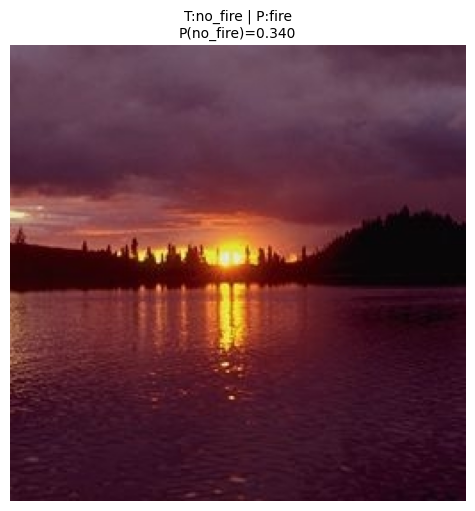

In [26]:
mis = test_df[~test_df["correct"]].head(MISCLASSIFIED_LIMIT)

if len(mis) > 0:
    cols = 3
    rows = math.ceil(len(mis) / cols)
    plt.figure(figsize=(15, 5 * rows))

    for i, (_, row) in enumerate(mis.iterrows()):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(row["filepath"]).convert("RGB")
        plt.imshow(img)
        plt.title(f"T:{row['true_name']} | P:{row['pred_name']}\nP(no_fire)={row['prob_no_fire']:.3f}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "plots", f"{MODEL_NAME}_misclassified_grid.png"), dpi=220)
    plt.show()

mis.to_csv(os.path.join(OUTPUT_DIR, "reports", f"{MODEL_NAME}_misclassified.csv"), index=False)

In [27]:
LAST_CONV_LAYER_NAME = "top_conv"
BACKBONE_NAME = "efficientnetb0"

print("Backbone:", BACKBONE_NAME)
print("Last conv layer:", LAST_CONV_LAYER_NAME)

Backbone: efficientnetb0
Last conv layer: top_conv


In [35]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

LAST_CONV_LAYER_NAME = "top_conv"
BACKBONE_NAME = "efficientnetb0"

def build_inference_model_from_trained_model(model, img_size=(224, 224)):
    # on récupère le backbone et les couches de la tête avec LES NOMS DE TON SUMMARY
    backbone = model.get_layer(BACKBONE_NAME)

    gap = model.get_layer("global_average_pooling2d")
    bn = model.get_layer("batch_normalization")
    dense1 = model.get_layer("dense")
    drop1 = model.get_layer("dropout")
    dense2 = model.get_layer("dense_1")
    drop2 = model.get_layer("dropout_1")
    dense_out = model.get_layer("dense_2")

    inputs = keras.Input(shape=img_size + (3,), name="gradcam_input")

    # pas d'augmentation -> preprocess + backbone + head
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = backbone(x, training=False)
    x = gap(x)
    x = bn(x, training=False)
    x = dense1(x)
    x = drop1(x, training=False)
    x = dense2(x)
    x = drop2(x, training=False)
    outputs = dense_out(x)

    inference_model = keras.Model(inputs, outputs, name="inference_model_no_aug")
    return inference_model

inference_model = build_inference_model_from_trained_model(model, img_size=IMG_SIZE)
inference_model.summary()

Model: "inference_model_no_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gradcam_input (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 2,996,289 (11.43 MB)

 Non-trainable params: 1,402,851 (5.35 MB)

In [36]:
gradcam_model = keras.models.Model(
    inputs=inference_model.input,
    outputs=[
        inference_model.get_layer(BACKBONE_NAME).get_layer(LAST_CONV_LAYER_NAME).output,
        inference_model.output
    ],
    name="gradcam_model"
)

gradcam_model.summary()

Model: "gradcam_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 2,996,289 (11.43 MB)

 Non-trainable params: 1,402,851 (5.35 MB)

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

LAST_CONV_LAYER_NAME = "top_conv"
BACKBONE_NAME = "efficientnetb0"

def build_inference_model_from_trained_model(model, img_size=(224, 224)):
    backbone = model.get_layer(BACKBONE_NAME)

    gap = model.get_layer("global_average_pooling2d")
    bn = model.get_layer("batch_normalization")
    dense1 = model.get_layer("dense")
    drop1 = model.get_layer("dropout")
    dense2 = model.get_layer("dense_1")
    drop2 = model.get_layer("dropout_1")
    dense_out = model.get_layer("dense_2")

    inputs = keras.Input(shape=img_size + (3,), name="gradcam_input")

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = backbone(x, training=False)
    x = gap(x)
    x = bn(x, training=False)
    x = dense1(x)
    x = drop1(x, training=False)
    x = dense2(x)
    x = drop2(x, training=False)
    outputs = dense_out(x)

    inference_model = keras.Model(inputs, outputs, name="inference_model_no_aug")
    return inference_model

inference_model = build_inference_model_from_trained_model(model, img_size=IMG_SIZE)
inference_model.summary()

Model: "inference_model_no_aug"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gradcam_input (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 2,996,289 (11.43 MB)

 Non-trainable params: 1,402,851 (5.35 MB)

In [39]:
# on récupère le backbone dans le modèle d'inférence
backbone_inf = inference_model.get_layer(BACKBONE_NAME)
last_conv_layer = backbone_inf.get_layer(LAST_CONV_LAYER_NAME)

# modèle qui donne (feature maps de top_conv, prédiction finale)
gradcam_model = keras.models.Model(
    inputs=inference_model.input,
    outputs=[last_conv_layer.output, inference_model.output],
    name="gradcam_model"
)

gradcam_model.summary()

Model: "gradcam_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 2,996,289 (11.43 MB)

 Non-trainable params: 1,402,851 (5.35 MB)

In [41]:
print("Résumé rapide:")
print(f"Accuracy test : {metrics_df.loc[0, 'accuracy']:.4f}")
print(f"Precision test: {metrics_df.loc[0, 'precision']:.4f}")
print(f"Recall test   : {metrics_df.loc[0, 'recall']:.4f}")
print(f"F1 test       : {metrics_df.loc[0, 'f1_score']:.4f}")
print(f"ROC-AUC test  : {metrics_df.loc[0, 'roc_auc']:.4f}")

Résumé rapide:
Accuracy test : 0.9974
Precision test: 1.0000
Recall test   : 0.9947
F1 test       : 0.9974
ROC-AUC test  : 1.0000
